In [1]:

#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.process_time_ns()
print('---------------------------------------')
print(time.strftime("PIXE_Intensities.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from PIXE_functions import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.process_time_ns()
elapsed_setup = (end_setup - start_setup)/1e6

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.2f} ms)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PIXE_Intensities.ipynb started: Mon, 23 Mar 2026 19:04:17
INFO: SETUP COMPLETE (16015.62 ms)
---------------------------------------


In [ ]:
K_name = ['Ertugral et al. (2006)', 'Ertugral et al. (2006)', 'Scofield (1974a)', 'Scofield (1974b)', 'Mason \& Kennedy (1974)', 'Salem et al. (1974)', 'Ertugrul et al. (2001)']
K_additions = ['exp. values', 'fit. values', 'theo. values (Hartree-Fock)', 'theo. values (Hartree-Slater)', 'theo. values (Hartree-Slater)', 'exp. values', 'exp. values']
K_scatter = ['x','o','v','<','>','s','D']
Kb1_Ka1 = {'Mn':[0.1440,0.1293,0.1385,0.1195,0.1194,-1,0.131],
           'Ni':[0.1330,0.1448,0.1401,0.1227,0.1221,0.135,0.135]}
Kb1_Ka1_err = {'Mn':[0.004,0,0,0,0,0,0.013],
               'Ni':[0.003,0,0,0,0,0.135*0.02,0.012]}

<>:1: SyntaxWarning: invalid escape sequence '\&'
<>:1: SyntaxWarning: invalid escape sequence '\&'
C:\Users\schum\AppData\Local\Temp\ipykernel_46788\403139953.py:1: SyntaxWarning: invalid escape sequence '\&'
  K_name = ['Ertugral et al. (2006)', 'Ertugral et al. (2006)', 'Scofield (1974a)', 'Scofield (1974b)', 'Mason \& Kennedy (1974)', 'Salem et al. (1974)', 'Ertugrul et al. (2001)']


In [91]:
def Kb1_Ka1_perElement(element:str, K_n:list, K_add:list, Kb1_Ka1:dict, Kb1_Ka1_err:dict, K_scatter:list):
    DPI = 300
    plt.figure(figsize=(5,3), dpi=DPI)
    data = Kb1_Ka1[element]
    errors = Kb1_Ka1_err[element]
    for i in range(len(data)):
        if (data[i] != -1):
            plt.errorbar(x=i,y=data[i],yerr=errors[i],markersize=3,capsize=2,fmt='',lw=0,elinewidth=0.6,ecolor='black',color='black',marker=K_scatter[i])
            plt.scatter([],[],s=8,lw=0.4,marker=K_scatter[i],color='black',label=f'{K_n[i]} \n {K_add[i]}')
    
    plt.ylabel(r'$K_{\beta}/K_{\alpha}$')
    
    plt.legend(fontsize=4)
    plt.show()

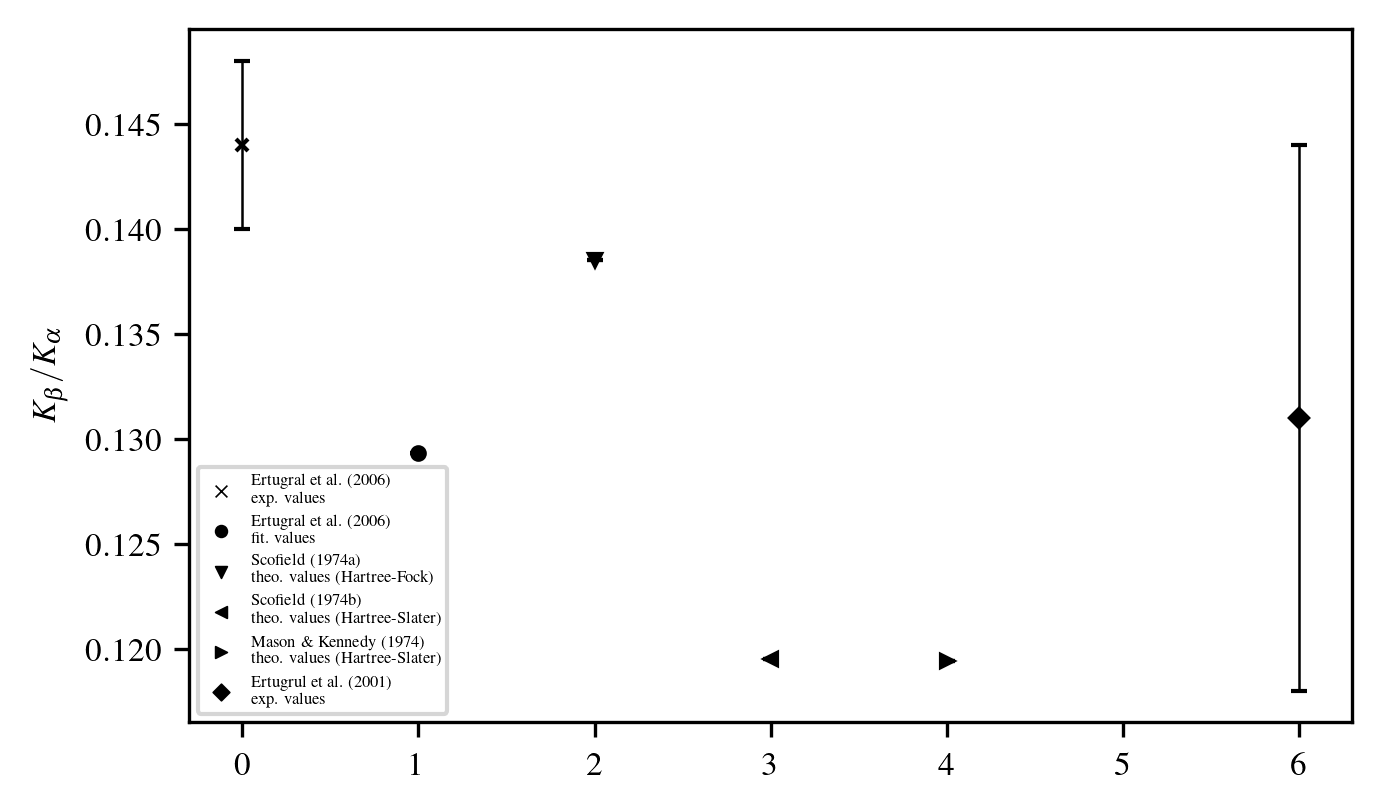

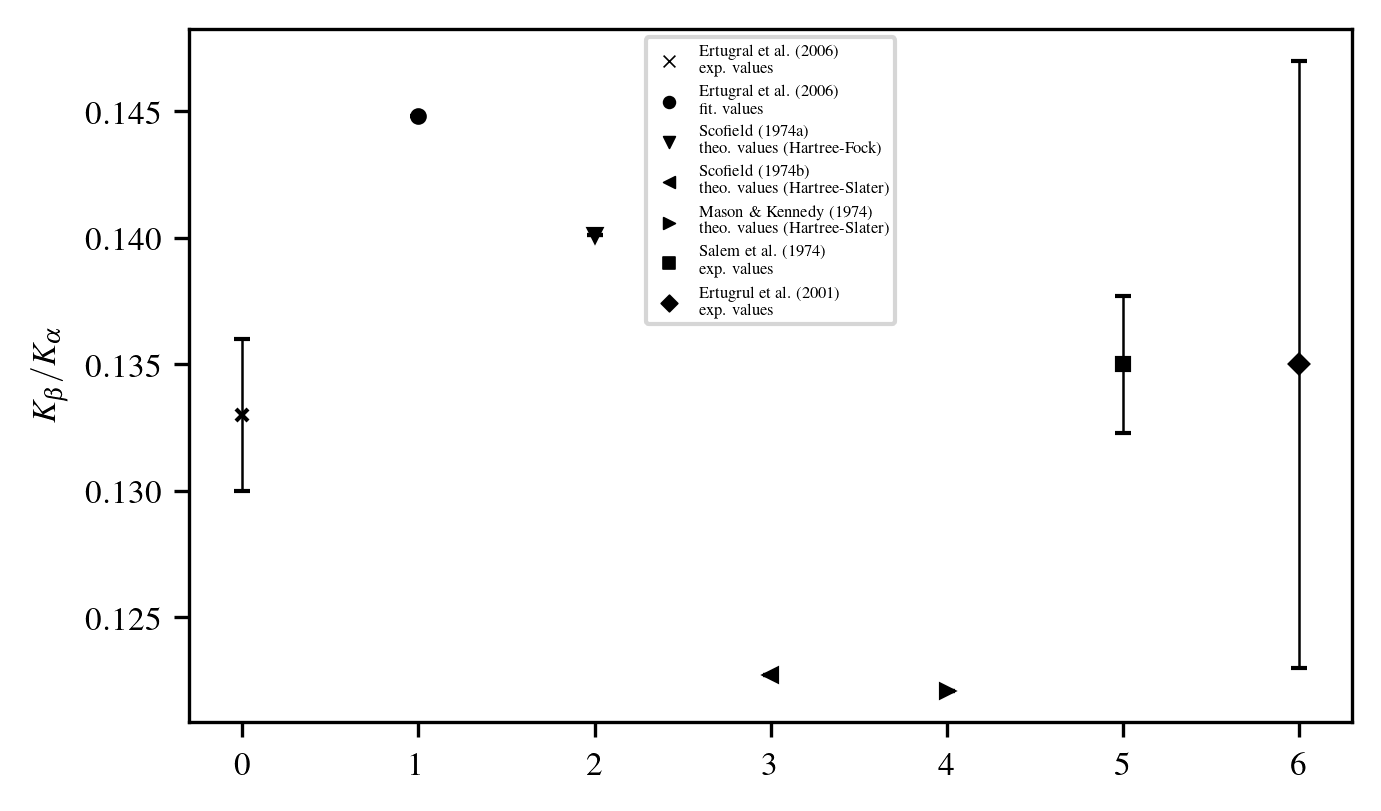

In [92]:
Kb1_Ka1_perElement('Mn', K_name, K_additions, Kb1_Ka1, Kb1_Ka1_err, K_scatter)
Kb1_Ka1_perElement('Ni', K_name, K_additions, Kb1_Ka1, Kb1_Ka1_err, K_scatter)